In [2]:
import pandas as pd
import numpy as np
from pprint import pprint

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score)
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [3]:
df = pd.read_csv('food_waste_data.csv')
print("Succesfully loaded the data.")
print(f"Shape: {df.shape}")

Succesfully loaded the data.
Shape: (1782, 11)


In [4]:
print(f"The first 5 rows of the dataset are :\n")
display(df.head())
print("\nDataset Information: \n")
display(df.info())

The first 5 rows of the dataset are :



,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25



Dataset Information: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Type of Food           1782 non-null   object
 1   Number of Guests       1782 non-null   int64 
 2   Event Type             1782 non-null   object
 3   Quantity of Food       1782 non-null   int64 
 4   Storage Conditions     1782 non-null   object
 5   Purchase History       1782 non-null   object
 6   Seasonality            1782 non-null   object
 7   Preparation Method     1782 non-null   object
 8   Geographical Location  1782 non-null   object
 9   Pricing                1782 non-null   object
 10  Wastage Food Amount    1782 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 153.3+ KB


None

In [5]:
print("Columns in the dataset: \n")
pprint(list(df.columns))
print("\nChecking for null values in the dataset: \n")
display(df.isnull().sum())

Columns in the dataset: 

['Type of Food',
 'Number of Guests',
 'Event Type',
 'Quantity of Food',
 'Storage Conditions',
 'Purchase History',
 'Seasonality',
 'Preparation Method',
 'Geographical Location',
 'Pricing',
 'Wastage Food Amount']

Checking for null values in the dataset: 



Type of Food             0
Number of Guests         0
Event Type               0
Quantity of Food         0
Storage Conditions       0
Purchase History         0
Seasonality              0
Preparation Method       0
Geographical Location    0
Pricing                  0
Wastage Food Amount      0
dtype: int64

In [6]:
print(df.describe())

print("\nCategorical Columns:")

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    
    print(f"\n{column}")
    print(df[column].value_counts())

       Number of Guests  Quantity of Food  Wastage Food Amount
count       1782.000000       1782.000000          1782.000000
mean         317.804714        411.125701            28.536476
std           67.829658         65.204674            10.461317
min          207.000000        280.000000            10.000000
25%          267.000000        350.000000            20.000000
50%          302.000000        400.000000            26.500000
75%          350.000000        480.000000            35.000000
max          491.000000        500.000000            63.000000

Categorical Columns:

Type of Food
Type of Food
Meat              437
Baked Goods       419
Dairy Products    387
Fruits            328
Vegetables        211
Name: count, dtype: int64

Event Type
Event Type
Corporate           515
Social Gathering    461
Wedding             438
Birthday            368
Name: count, dtype: int64

Storage Conditions
Storage Conditions
Room Temperature    1157
Refrigerated         625
Name: count, d

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

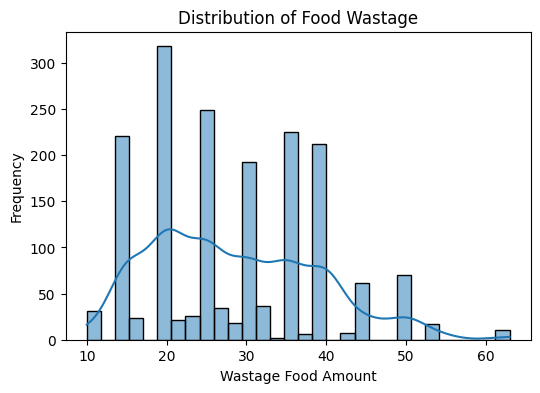

In [8]:
plt.figure(figsize=(6, 4))

sns.histplot(df["Wastage Food Amount"], bins=30, kde=True)

plt.title("Distribution of Food Wastage")
plt.xlabel("Wastage Food Amount")
plt.ylabel("Frequency")

plt.show()

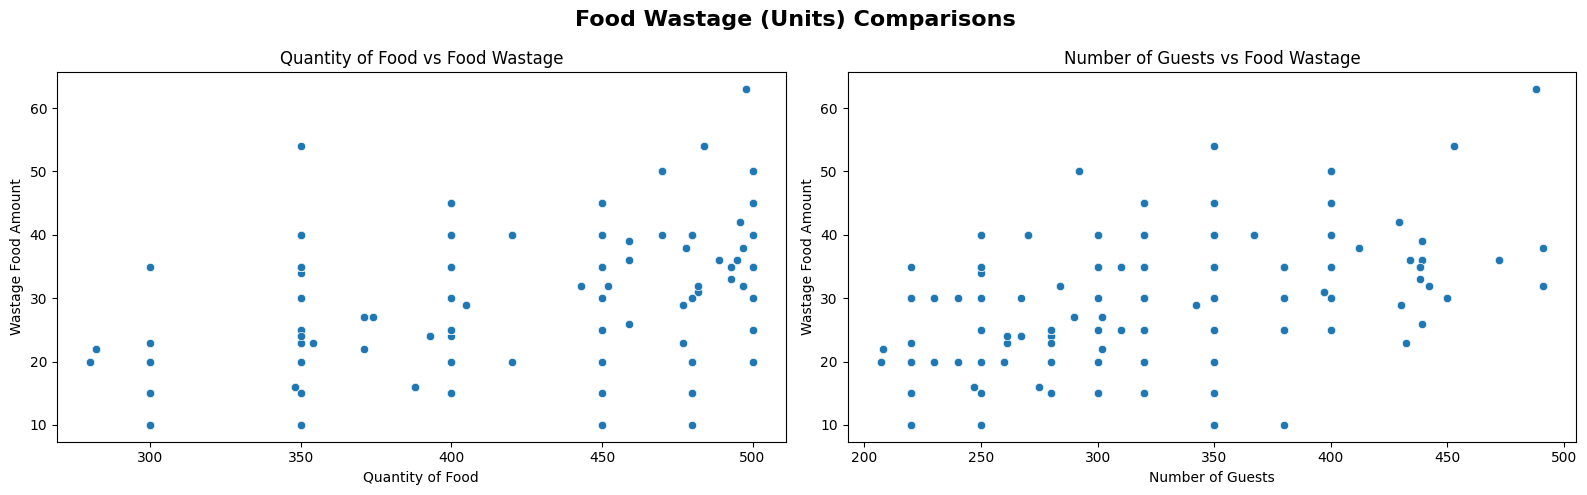

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Food Wastage (Units) Comparisons", fontsize=16, fontweight="bold")

# Quantity of Food vs Food Wastage
sns.scatterplot(
    data=df,
    x="Quantity of Food",
    y="Wastage Food Amount",
    ax=axes[0]
)
axes[0].set_title("Quantity of Food vs Food Wastage")


# Number of Guests vs Food Wastage
sns.scatterplot(
    data=df,
    x="Number of Guests",
    y="Wastage Food Amount",
    ax=axes[1]
)
axes[1].set_title("Number of Guests vs Food Wastage")

plt.tight_layout()
plt.show()

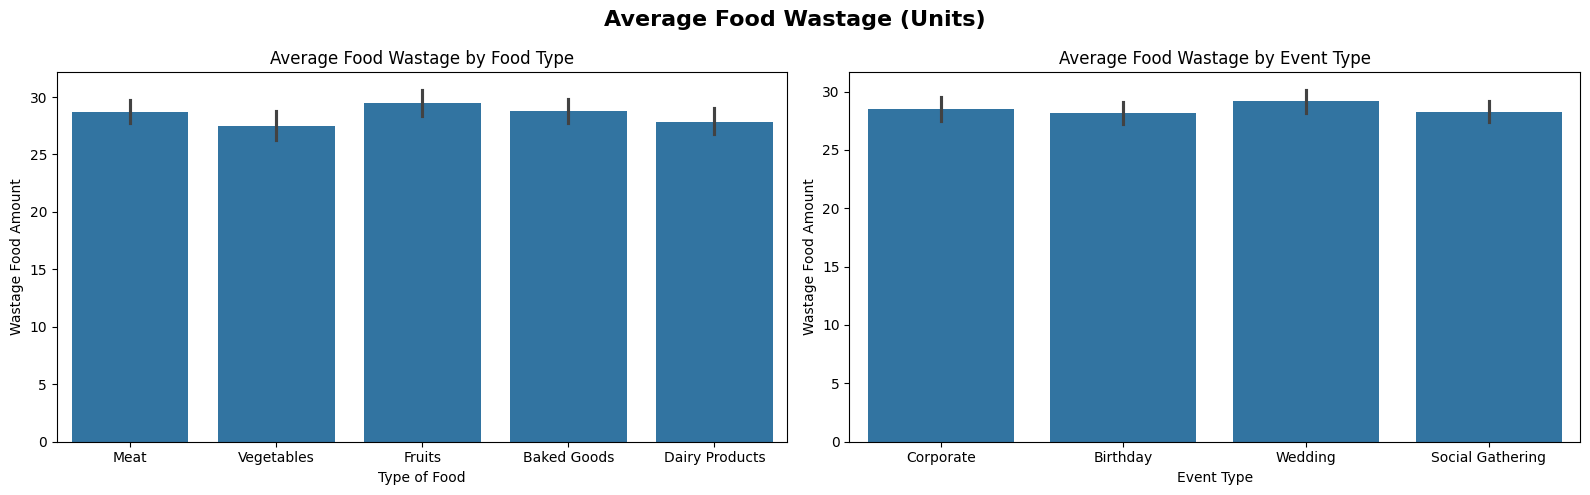

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Average Food Wastage (Units)", fontsize=16, fontweight="bold")

# Average Food Wastage by Food Type
sns.barplot(
    data=df,
    x="Type of Food",
    y="Wastage Food Amount",
    ax=axes[0]
)

axes[0].set_title("Average Food Wastage by Food Type")


# Average Food Wastage by Event Type
sns.barplot(
    data=df,
    x="Event Type",
    y="Wastage Food Amount",
    ax=axes[1]
)
axes[1].set_title("Average Food Wastage by Event Type")

plt.tight_layout()
plt.show()

In [11]:
df["Food_Per_Guest"] = (df["Quantity of Food"] / df["Number of Guests"])

#Checking the distribution of Food_Per_Guest: 
df[["Number of Guests", "Quantity of Food", "Food_Per_Guest", "Wastage Food Amount"]].head()

,Number of Guests,Quantity of Food,Food_Per_Guest,Wastage Food Amount
0,310,450,1.451613,25
1,400,500,1.250000,40
2,302,371,1.228477,27
3,491,497,1.012220,32
4,300,400,1.333333,25


In [12]:
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr()

# Display correlation matrix
display(correlation_matrix)

,Number of Guests,Quantity of Food,Wastage Food Amount,Food_Per_Guest
Number of Guests,1.000000,0.794401,0.650421,-0.598149
Quantity of Food,0.794401,1.000000,0.638648,-0.009096
Wastage Food Amount,0.650421,0.638648,1.000000,-0.242769
Food_Per_Guest,-0.598149,-0.009096,-0.242769,1.000000


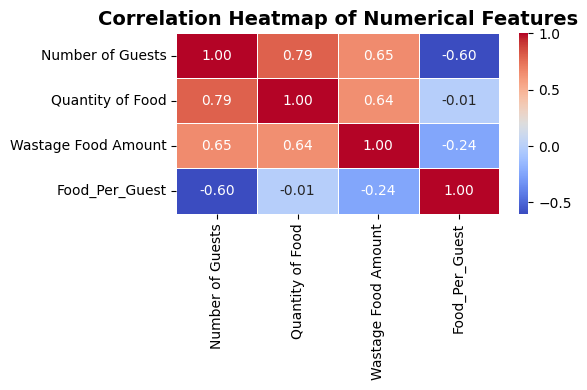

In [13]:
plt.figure(figsize=(6, 4))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [14]:
numerical_columns = [
    "Number of Guests",
    "Quantity of Food",
    "Wastage Food Amount"
]

for column in numerical_columns:
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    print(f"\n{column}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of Outliers: {len(outliers)}")


Number of Guests
Q1: 267.0
Q3: 350.0
IQR: 83.0
Lower Bound: 142.5
Upper Bound: 474.5
Number of Outliers: 35

Quantity of Food
Q1: 350.0
Q3: 480.0
IQR: 130.0
Lower Bound: 155.0
Upper Bound: 675.0
Number of Outliers: 0

Wastage Food Amount
Q1: 20.0
Q3: 35.0
IQR: 15.0
Lower Bound: -2.5
Upper Bound: 57.5
Number of Outliers: 10


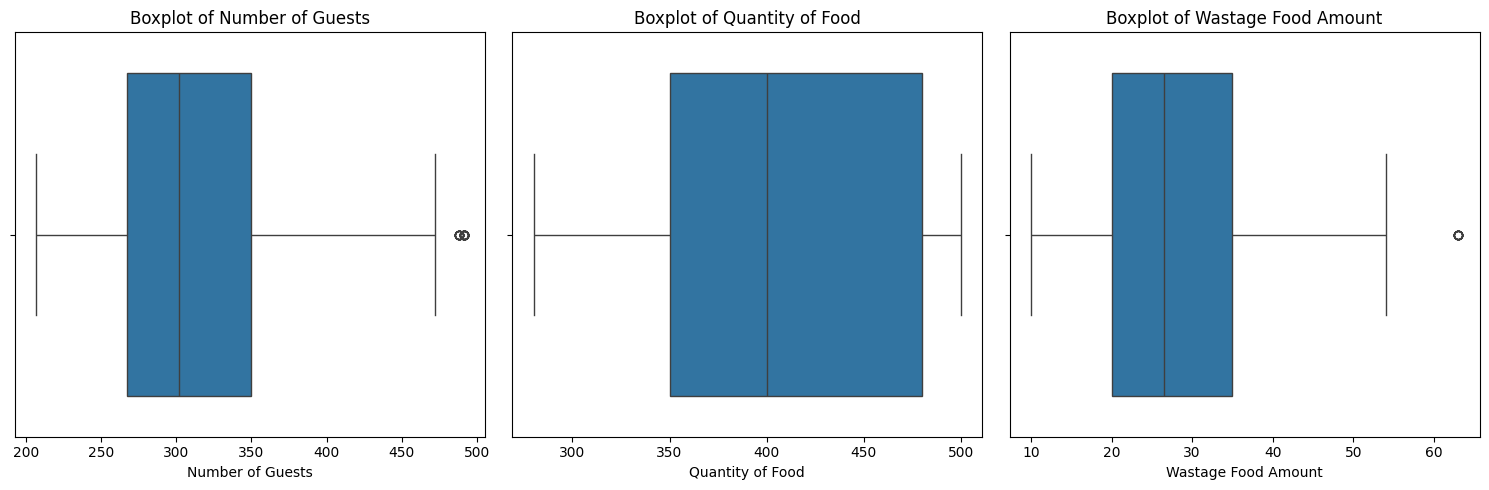

In [15]:
numerical_columns = [
    "Number of Guests",
    "Quantity of Food",
    "Wastage Food Amount"
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

for i, column in enumerate(numerical_columns):
    
    sns.boxplot(
        x=df[column],
        ax=axes[i]
    )
    
    axes[i].set_title(f"Boxplot of {column}")
    axes[i].set_xlabel(column)

plt.tight_layout()
plt.show()

In [16]:
df_clean = df.copy()

for column in numerical_columns:
    
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_clean = df_clean[
        (df_clean[column] >= lower_bound) &
        (df_clean[column] <= upper_bound)
    ]

print("Original rows:", len(df))
print("Rows after removing outliers:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 1782
Rows after removing outliers: 1747
Rows removed: 35


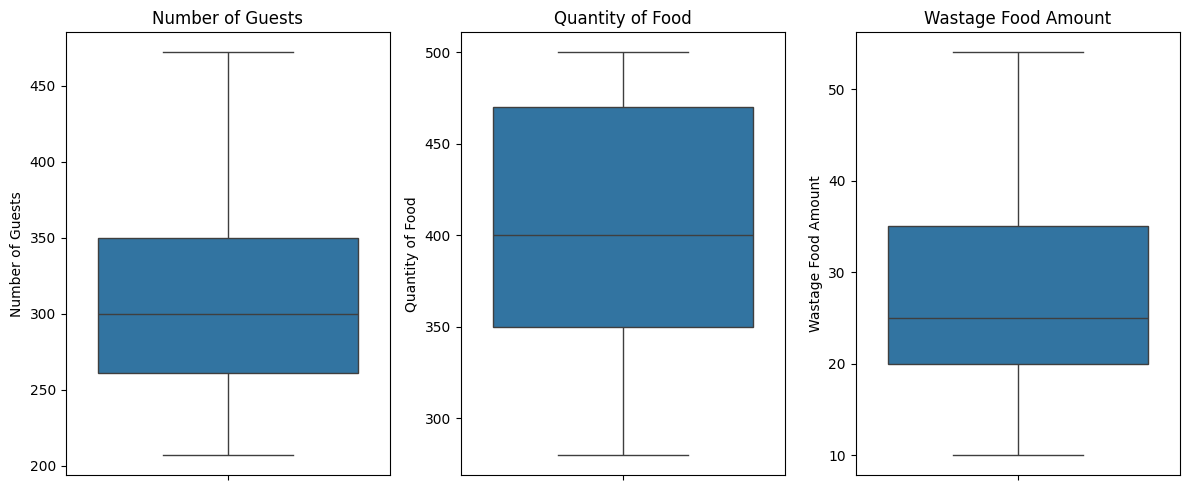

In [17]:

plt.figure(figsize=(12, 5))

for i, column in enumerate(numerical_columns, 1):
    
    plt.subplot(1, 3, i)
    
    sns.boxplot(y=df_clean[column])
    
    plt.title(column)

plt.tight_layout()
plt.show()

In [18]:
X = df_clean.drop(
    "Wastage Food Amount",
    axis=1
)

y = df_clean["Wastage Food Amount"]

In [19]:
categorical_columns = [
    "Type of Food",
    "Event Type",
    "Storage Conditions",
    "Purchase History",
    "Seasonality",
    "Preparation Method",
    "Geographical Location",
    "Pricing"
]

numerical_columns = [
    "Number of Guests",
    "Quantity of Food",
    "Food_Per_Guest"
]

In [20]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1397, 11)
Testing Data: (350, 11)


In [22]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = (
    mean_squared_error(
        y_test,
        linear_predictions
    )
) ** 0.5

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression")

print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R² Score:", linear_r2)

Linear Regression
MAE: 3.4910375933447364
RMSE: 4.438779895147996
R² Score: 0.8139060847266026


In [23]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=10,
                random_state=42
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = (
    mean_squared_error(
        y_test,
        rf_predictions
    )
) ** 0.5

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest")

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest
MAE: 1.7126537677866462
RMSE: 2.8072529981307723
R² Score: 0.9255665650441542


In [24]:

gb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gb_model.fit(
    X_train,
    y_train
)

gb_predictions = gb_model.predict(
    X_test
)

gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = (
    mean_squared_error(
        y_test,
        gb_predictions
    )
) ** 0.5

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

print("Gradient Boosting")

print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R² Score:", gb_r2)

Gradient Boosting
MAE: 2.0579094456399143
RMSE: 2.8921275723432855
R² Score: 0.9209976801299762


In [25]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    
    "R2 Score": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

results = results.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

display(results.style.hide(axis = 'index'))

Model,MAE,RMSE,R2 Score
Random Forest,1.712654,2.807253,0.925567
Gradient Boosting,2.057909,2.892128,0.920998
Linear Regression,3.491038,4.438780,0.813906


In [26]:
# import joblib

# joblib.dump(rf_model, "food_waste_model.pkl")

In [ ]:
from xgboost import XGBRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np



# 1. Categorical columns


categorical_columns = [
    "Type of Food",
    "Event Type",
    "Storage Conditions",
    "Purchase History",
    "Seasonality",
    "Preparation Method",
    "Geographical Location",
    "Pricing"
]



# 2. Encode categorical columns


preprocessor_xgb = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor_xgb.fit_transform(X_train)
X_test_encoded = preprocessor_xgb.transform(X_test)



# 3. XGBoost model


xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=2
)



# 4. Hyperparameter search


param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}



# 5. RandomizedSearchCV


xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=15,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=1,
    verbose=1
)



# 6. Train


xgb_search.fit(
    X_train_encoded,
    y_train
)



# 7. Best model


best_xgb = xgb_search.best_estimator_



# 8. Prediction


y_pred = best_xgb.predict(X_test_encoded)



# 9. Evaluation


mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)



# 10. Results


print("\n==============================")
print("TUNED XGBOOST RESULTS")
print("==============================")

print("\nBest Parameters:")
print(xgb_search.best_params_)

print("\nBest CV R²:")
print(xgb_search.best_score_)

print("\nTest MAE :", mae)
print("Test RMSE:", rmse)
print("Test R²  :", r2)

Fitting 5 folds for each of 15 candidates, totalling 75 fits

TUNED XGBOOST RESULTS

Best Parameters:
{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.8}

Best CV R²:
0.9162260293960571

Test MAE : 1.8066716194152832
Test RMSE: 2.6710073389590208
Test R²  : 0.9326162338256836


In [36]:
import joblib

xgb_pipeline = {
    "model": best_xgb,
    "preprocessor": preprocessor_xgb
}

joblib.dump(
    xgb_pipeline,
    "food_waste_xgb_pipeline.pkl"
)

print("XGBoost pipeline saved successfully!")

XGBoost pipeline saved successfully!
